# Product & Payment Lens on Delivery/Review Performance

This notebook investigates the "delivery/review problem through product/payment lens" branch of the
storyline: does product weight/volume, or payment method, relate to delivery
days / lateness and review scores?

Uses `data/smartcommerce_consolidated.csv` (the shared, pre-joined base the
rest of the dashboard reads from) + two **temporary** merges: product
dimensions and payment info, which exist only as in-memory DataFrames here.


## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = next(
    (root / "data" for root in (Path.cwd(), *Path.cwd().parents)
     if (root / "data" / "olist_orders_dataset.csv").is_file()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find the repository data/ directory")
CONSOLIDATED_PATH = DATA_DIR / "smartcommerce_consolidated.csv"
PRODUCTS_PATH = DATA_DIR / "olist_products_dataset.csv"
PAYMENTS_PATH = DATA_DIR / "olist_order_payments_dataset.csv"
REVIEWS_PATH = DATA_DIR / "olist_order_reviews_dataset.csv"


mkdir -p failed for path /Users/joshualum/.matplotlib: [Errno 1] Operation not permitted: '/Users/joshualum/.matplotlib'


Matplotlib created a temporary cache directory at /var/folders/lh/h9px96k96s33hykt549wrwv00000gn/T/matplotlib-4yjhq3rm because there was an issue with the default path (/Users/joshualum/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
items = pd.read_csv(CONSOLIDATED_PATH)
print(f"{len(items):,} item rows, {items['order_id'].nunique():,} distinct orders")
items[["order_id", "order_item_id", "product_id", "seller_id", "product_weight_g",
       "delivery_days", "is_on_time", "order_status"]].head()


112,650 item rows, 98,666 distinct orders


,order_id,order_item_id,product_id,seller_id,product_weight_g,delivery_days,is_on_time,order_status
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,650.0,7.0,True,delivered
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,30000.0,16.0,True,delivered
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,3050.0,7.0,True,delivered
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,200.0,6.0,True,delivered
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,3750.0,25.0,True,delivered


this file is at *item* level
(`order_item_id`), but `delivery_days`/`is_on_time` are *order*-level facts —
same order → same value on every item row. Confirmed already (every order has
exactly one distinct `delivery_days` and one distinct `is_on_time` value), so
it's safe to aggregate item rows up to one row per order without worrying
about conflicting labels. Also: `delivery_days` is only populated for
`delivered` orders with a real delivery date — filter on it being non-null
rather than filtering `order_status` directly, same convention the rest of
`dashboard_data.py` uses (`eligible_deliveries`).


In [3]:
eligible = items[items["delivery_days"].notna()].copy()
eligible["is_late"] = ~eligible["is_on_time"].astype(bool)
print(f"{len(eligible):,} eligible item rows across {eligible['order_id'].nunique():,} delivered orders")


110,196 eligible item rows across 96,476 delivered orders


## 1. Product weight vs. delivery performance

Weight is summed **per order** (total shipment weight), not looked at per
item — a 3kg order made of one heavy item behaves the same, shipping-wise, as
one made of three 1kg items. Item-level weight would also double-count
multi-item orders in any per-order aggregate (mean delivery_days by weight
bucket, etc.).


In [4]:
order_weight = eligible.groupby("order_id").agg(
    total_weight_g=("product_weight_g", "sum"),
    delivery_days=("delivery_days", "first"),
    is_late=("is_late", "first"),
).reset_index()

order_weight = order_weight.dropna(subset=["total_weight_g"])
print(f"{len(order_weight):,} orders with weight data")
order_weight[["total_weight_g", "delivery_days"]].describe()


96,476 orders with weight data


,total_weight_g,delivery_days
count,96476.000000,96476.000000
mean,2386.396627,12.094086
std,4769.678332,9.551746
min,0.000000,0.000000
25%,300.000000,6.000000
50%,750.000000,10.000000
75%,2050.000000,15.000000
max,184400.000000,209.000000


### 1.1 Raw correlation


In [5]:
pearson_r = order_weight["total_weight_g"].corr(order_weight["delivery_days"], method="pearson")
spearman_r = order_weight["total_weight_g"].corr(order_weight["delivery_days"], method="spearman")
print(f"Pearson r  (weight vs delivery_days): {pearson_r:.3f}")
print(f"Spearman r (weight vs delivery_days): {spearman_r:.3f}")

# point-biserial style: does weight differ between late and on-time orders?
weight_by_lateness = order_weight.groupby("is_late")["total_weight_g"].mean()
print()
print("Mean total_weight_g by lateness:")
print(weight_by_lateness)


Pearson r  (weight vs delivery_days): 0.071
Spearman r (weight vs delivery_days): 0.087

Mean total_weight_g by lateness:
is_late
False    2361.046753
True     2735.286151
Name: total_weight_g, dtype: float64


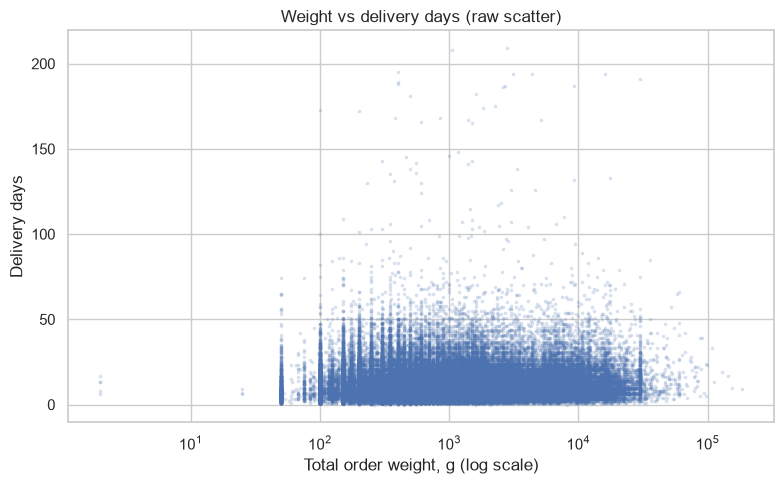

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(order_weight["total_weight_g"], order_weight["delivery_days"], s=3, alpha=0.15)
ax.set_xscale("log")
ax.set_xlabel("Total order weight, g (log scale)")
ax.set_ylabel("Delivery days")
ax.set_title("Weight vs delivery days (raw scatter)")
plt.tight_layout()
plt.show()


### 1.2 Bucket analysis — is this a better view than the raw correlation?


        weight_bucket  mean_delivery_days  late_rate  orders
0     (-0.001, 250.0]           11.189237   6.078775   20514
1      (250.0, 500.0]           11.847761   7.025582   18333
2     (500.0, 1100.0]           11.893262   6.244752   19056
3    (1100.0, 2800.0]           12.307486   7.028112   19422
4  (2800.0, 184400.0]           13.282544   7.545298   19151


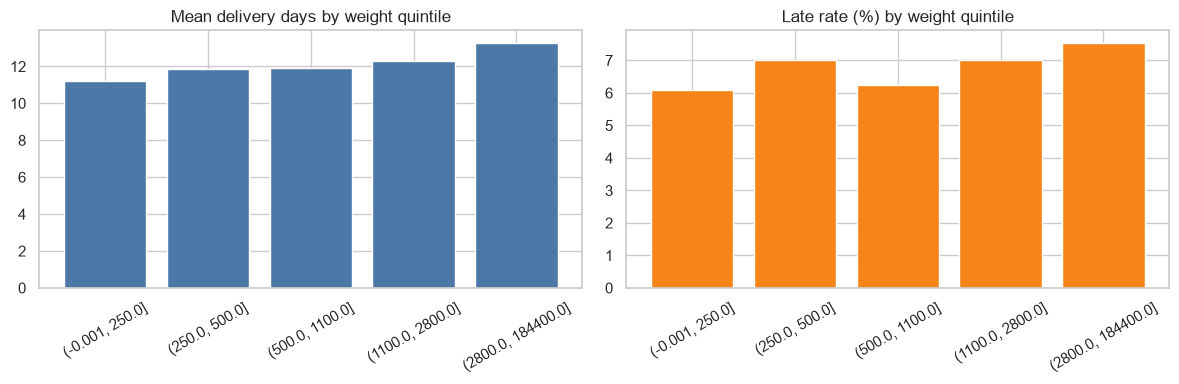

In [7]:
order_weight["weight_bucket"] = pd.qcut(
    order_weight["total_weight_g"], q=5, duplicates="drop"
)
weight_summary = order_weight.groupby("weight_bucket", observed=True).agg(
    mean_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    orders=("order_id", "size"),
).reset_index()
weight_summary["late_rate"] *= 100
print(weight_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(weight_summary["weight_bucket"].astype(str), weight_summary["mean_delivery_days"], color="#4C78A8")
axes[0].set_title("Mean delivery days by weight quintile")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(weight_summary["weight_bucket"].astype(str), weight_summary["late_rate"], color="#F58518")
axes[1].set_title("Late rate (%) by weight quintile")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


Mean recorded whole-day delivery time rises from 11.19 days in the lightest weight quintile to 13.28 days in the heaviest. Pearson and Spearman correlations remain weak (0.071 and 0.087). Calendar-date late rates are 6.08%, 7.03%, 6.24%, 7.03%, and 7.55% across the quintiles, so lateness does not rise monotonically. Each bucket contains about 18,300–20,500 orders. These are unadjusted associations; distance and seller mix have not been controlled for.

## 2. Product volume vs. delivery performance

`smartcommerce_consolidated.csv` only carries `product_weight_g` — length/
height/width live in the raw products file. Merged in here as a **new,
temporary DataFrame**.


In [8]:
products_dims = pd.read_csv(
    PRODUCTS_PATH,
    usecols=["product_id", "product_length_cm", "product_height_cm", "product_width_cm"],
)
products_dims["volume_cm3"] = (
    products_dims["product_length_cm"]
    * products_dims["product_height_cm"]
    * products_dims["product_width_cm"]
)
print(f"{products_dims['volume_cm3'].notna().sum():,} of {len(products_dims):,} products have full dimensions")
products_dims[["volume_cm3"]].describe()


32,949 of 32,951 products have full dimensions


,volume_cm3
count,32949.000000
mean,16564.096695
std,27057.041650
min,168.000000
25%,2880.000000
50%,6840.000000
75%,18480.000000
max,296208.000000


In [9]:
# attach per-item volume, then sum to order level (same reasoning as weight: total
# shipment volume, not per-item)
items_with_volume = eligible.merge(products_dims[["product_id", "volume_cm3"]], on="product_id", how="left")

order_volume = items_with_volume.groupby("order_id").agg(
    total_volume_cm3=("volume_cm3", "sum"),
    delivery_days=("delivery_days", "first"),
    is_late=("is_late", "first"),
).reset_index()
order_volume = order_volume.dropna(subset=["total_volume_cm3"])
print(f"{len(order_volume):,} orders with volume data")
order_volume[["total_volume_cm3", "delivery_days"]].describe()


96,476 orders with volume data


,total_volume_cm3,delivery_days
count,9.647600e+04,96476.000000
mean,1.732868e+04,12.094086
std,3.014143e+04,9.551746
min,0.000000e+00,0.000000
25%,2.964000e+03,6.000000
50%,7.250000e+03,10.000000
75%,1.986600e+04,15.000000
max,1.476000e+06,209.000000


### 2.1 Raw correlation


In [10]:
pearson_r_vol = order_volume["total_volume_cm3"].corr(order_volume["delivery_days"], method="pearson")
spearman_r_vol = order_volume["total_volume_cm3"].corr(order_volume["delivery_days"], method="spearman")
print(f"Pearson r  (volume vs delivery_days): {pearson_r_vol:.3f}")
print(f"Spearman r (volume vs delivery_days): {spearman_r_vol:.3f}")

volume_by_lateness = order_volume.groupby("is_late")["total_volume_cm3"].mean()
print()
print("Mean total_volume_cm3 by lateness:")
print(volume_by_lateness)


Pearson r  (volume vs delivery_days): 0.063
Spearman r (volume vs delivery_days): 0.068

Mean total_volume_cm3 by lateness:
is_late
False    17205.281040
True     19026.985463
Name: total_volume_cm3, dtype: float64


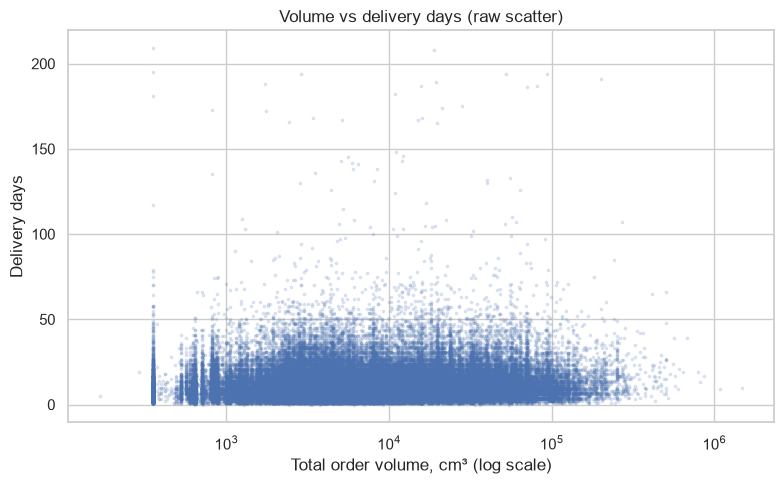

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(order_volume["total_volume_cm3"], order_volume["delivery_days"], s=3, alpha=0.15)
ax.set_xscale("log")
ax.set_xlabel("Total order volume, cm³ (log scale)")
ax.set_ylabel("Delivery days")
ax.set_title("Volume vs delivery days (raw scatter)")
plt.tight_layout()
plt.show()


### 2.2 Bucket analysis


          volume_bucket  mean_delivery_days  late_rate  orders
0      (-0.001, 2520.0]           11.383589   6.234926   19487
1      (2520.0, 4800.0]           12.016889   7.247059   19125
2     (4800.0, 10260.0]           11.792081   6.115257   19296
3    (10260.0, 24276.0]           12.331846   7.066514   19274
4  (24276.0, 1476000.0]           12.952731   7.214678   19294


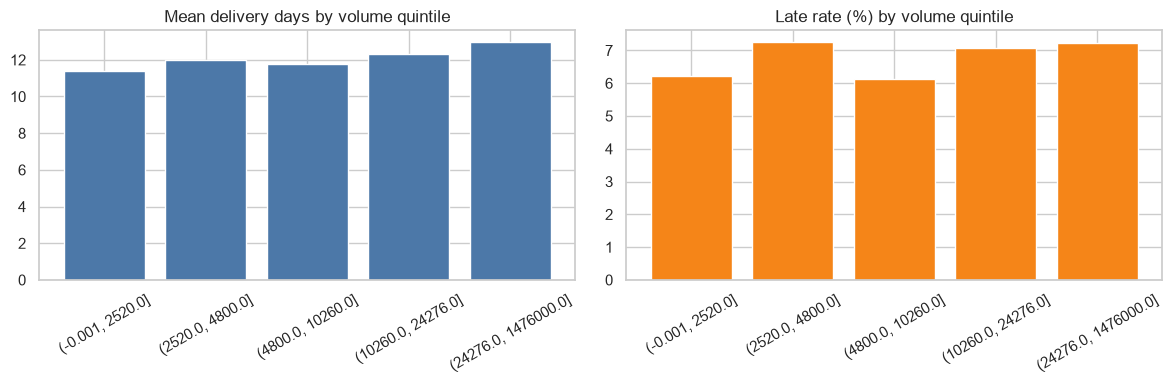

In [12]:
order_volume["volume_bucket"] = pd.qcut(
    order_volume["total_volume_cm3"], q=5, duplicates="drop"
)
volume_summary = order_volume.groupby("volume_bucket", observed=True).agg(
    mean_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    orders=("order_id", "size"),
).reset_index()
volume_summary["late_rate"] *= 100
print(volume_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(volume_summary["volume_bucket"].astype(str), volume_summary["mean_delivery_days"], color="#4C78A8")
axes[0].set_title("Mean delivery days by volume quintile")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(volume_summary["volume_bucket"].astype(str), volume_summary["late_rate"], color="#F58518")
axes[1].set_title("Late rate (%) by volume quintile")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [13]:
weight_volume_corr = order_weight.merge(
    order_volume[["order_id", "total_volume_cm3"]], on="order_id", how="inner"
)
print("Correlation between total_weight_g and total_volume_cm3:",
      f"{weight_volume_corr['total_weight_g'].corr(weight_volume_corr['total_volume_cm3']):.3f}")


Correlation between total_weight_g and total_volume_cm3: 0.828


**Volume gives a weaker, less consistent size signal than weight.** Pearson and Spearman correlations with recorded delivery days are 0.063 and 0.068. Mean delivery days across volume quintiles are 11.38, 12.02, 11.79, 12.33, and 12.95; calendar-date late rates are 6.23%, 7.25%, 6.12%, 7.07%, and 7.21%. The middle quintile dips in both series. Weight and volume are strongly correlated (r = 0.828), so whether volume adds useful information beyond weight requires an adjusted, out-of-sample model.

## 3. Order size & single- vs. multi-seller orders

Two separate questions here: does buying *more items* in one order slow
delivery down, and does it matter whether those items came
from *one seller* or were *combined from several sellers* in a single
checkout?

In [14]:
order_composition = eligible.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_distinct_sellers=("seller_id", "nunique"),
    delivery_days=("delivery_days", "first"),
    is_late=("is_late", "first"),
).reset_index()

print(order_composition["n_items"].value_counts().sort_index().head(10))


n_items
1     86840
2      7393
3      1306
4       495
5       193
6       191
7        22
8         8
9         3
10        8
Name: count, dtype: int64


### 3.1 Number of items per order

  n_items_bucket  mean_delivery_days  late_rate  orders
0         1 item           12.175196   6.938047   86840
1      2–3 items           11.331417   5.299460    8699
2       4+ items           11.657417   5.229456     937


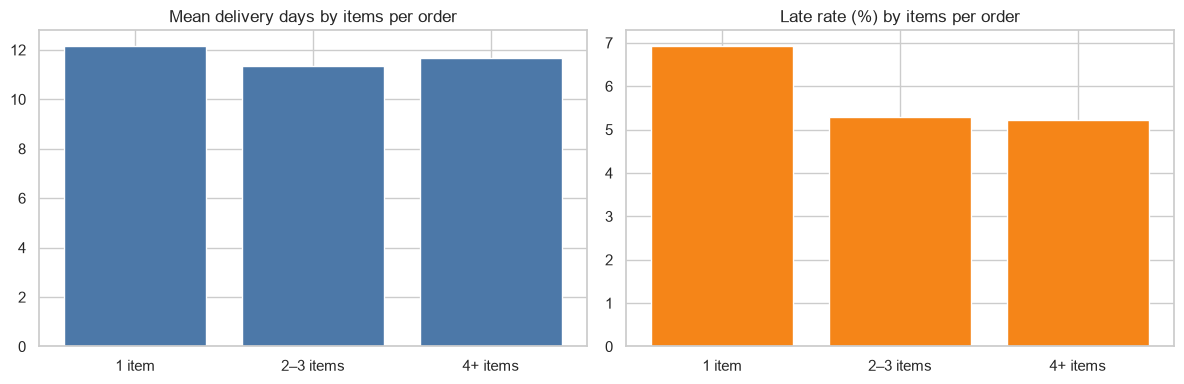

In [15]:
order_composition["n_items_bucket"] = pd.cut(
    order_composition["n_items"],
    bins=[0, 1, 3, order_composition["n_items"].max()],
    labels=["1 item", "2–3 items", "4+ items"],
)

items_summary = order_composition.groupby("n_items_bucket", observed=True).agg(
    mean_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    orders=("order_id", "size"),
).reset_index()
items_summary["late_rate"] *= 100
print(items_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(items_summary["n_items_bucket"].astype(str), items_summary["mean_delivery_days"], color="#4C78A8")
axes[0].set_title("Mean delivery days by items per order")
axes[1].bar(items_summary["n_items_bucket"].astype(str), items_summary["late_rate"], color="#F58518")
axes[1].set_title("Late rate (%) by items per order")
plt.tight_layout()
plt.show()


- 1 item: 12.18 recorded whole days, 6.94% late (n = 86,840)
- 2–3 items: 11.33 days, 5.30% late (n = 8,699)
- 4+ items: 11.66 days, 5.23% late (n = 937)

Multi-item orders in this delivered cohort are faster and less often late than single-item orders. The 4+ group is small, and these comparisons do not explain the mechanism or establish a causal benefit from adding items.

### 3.2 Single-seller vs. multi-seller orders

Restricted to orders with **more than one item**: a 1-item order is trivially "single seller", so mixing those in would just be re-measuring
3.1's item-count effect under a different name. 

This isolates the actual question: *given* a multi-item order, does it matter whether those items came
from one seller or were combined from several?

         seller_mix  mean_delivery_days  late_rate  orders
0  Multiple sellers            8.662745   1.019608    1275
1     Single seller           11.774907   5.944265    8361


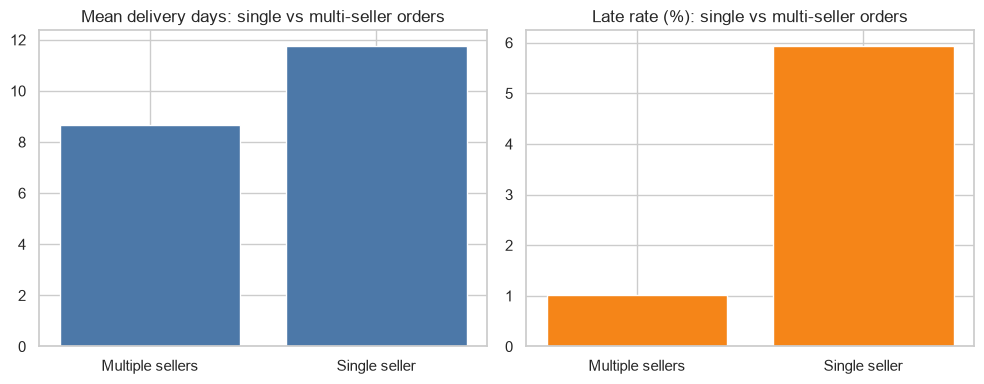

In [16]:
multi_item_orders = order_composition[order_composition["n_items"] > 1].copy()
multi_item_orders["seller_mix"] = multi_item_orders["n_distinct_sellers"].map(
    lambda n: "Single seller" if n == 1 else "Multiple sellers"
)

seller_mix_summary = multi_item_orders.groupby("seller_mix").agg(
    mean_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    orders=("order_id", "size"),
).reset_index()
seller_mix_summary["late_rate"] *= 100
print(seller_mix_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(seller_mix_summary["seller_mix"], seller_mix_summary["mean_delivery_days"], color="#4C78A8")
axes[0].set_title("Mean delivery days: single vs multi-seller orders")
axes[1].bar(seller_mix_summary["seller_mix"], seller_mix_summary["late_rate"], color="#F58518")
axes[1].set_title("Late rate (%): single vs multi-seller orders")
plt.tight_layout()
plt.show()


Among **multi-item delivered orders only**:

- Multiple sellers: 8.66 recorded whole days, 1.02% late (n = 1,275)
- Single seller: 11.77 days, 5.94% late (n = 8,361)

The multi-seller group is small. This is an unadjusted comparison of delivered orders and may reflect product, geography, timing, or selection differences; it should not be treated as a causal seller-count effect.

### 3.3 Checking the survivorship-bias concern from 3.2

Testing: does `order_status` (all orders, not just delivered ones) show a higher cancellation rate for multi-seller orders?

In [17]:
all_composition = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_distinct_sellers=("seller_id", "nunique"),
    order_status=("order_status", "first"),
).reset_index()

all_multi_item = all_composition[all_composition["n_items"] > 1].copy()
all_multi_item["seller_mix"] = all_multi_item["n_distinct_sellers"].map(
    lambda n: "Single seller" if n == 1 else "Multiple sellers"
)
all_multi_item["is_canceled"] = all_multi_item["order_status"].eq("canceled")

cancellation_summary = all_multi_item.groupby("seller_mix").agg(
    orders=("order_id", "size"),
    canceled_rate=("is_canceled", "mean"),
).reset_index()
cancellation_summary["canceled_rate"] *= 100
print(cancellation_summary)


         seller_mix  orders  canceled_rate
0  Multiple sellers    1278       0.000000
1     Single seller    8525       0.480938


**Cancellation check:** Among all orders in the two multi-item groups, no multi-seller orders were marked canceled (0 of 1,278), versus 41 of 8,525 single-seller orders (0.48%). This does not support the proposed explanation that multi-seller orders look faster because they cancel more often. It does not rule out other forms of selection or confounding, and the mechanism behind the delivery difference remains unknown.

## 4. Payment method vs. delivery performance

Payment info isn't in the consolidated file either. Merged in here as another **temporary** DataFrame.

An order can have more than one payment row (e.g. a voucher topped up with a credit card):
`payment_sequential == 1` is Olist's primary payment record.


In [18]:
payments = pd.read_csv(PAYMENTS_PATH)
dup_share = (payments["order_id"].duplicated()).mean()
print(f"{dup_share:.1%} of payment rows belong to an order with >1 payment row")

primary_payment = (
    payments[payments["payment_sequential"] == 1]
    [["order_id", "payment_type", "payment_installments"]]
)
print(f"{len(primary_payment):,} orders have a primary (sequential==1) payment row")


4.3% of payment rows belong to an order with >1 payment row
99,360 orders have a primary (sequential==1) payment row


In [19]:
order_outcomes = eligible.drop_duplicates("order_id")[["order_id", "delivery_days", "is_late"]]
order_payment = order_outcomes.merge(primary_payment, on="order_id", how="inner")
print(f"{len(order_payment):,} of {len(order_outcomes):,} eligible orders matched to a primary payment record")

payment_summary = order_payment.groupby("payment_type").agg(
    mean_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    orders=("order_id", "size"),
).sort_values("orders", ascending=False).reset_index()
payment_summary["late_rate"] *= 100
payment_summary


96,397 of 96,476 eligible orders matched to a primary payment record


,payment_type,mean_delivery_days,late_rate,orders
0,credit_card,11.883741,6.675283,74274
1,boleto,13.039969,7.321522,19190
2,voucher,12.015354,5.807744,1498
3,debit_card,10.214634,5.365854,1435


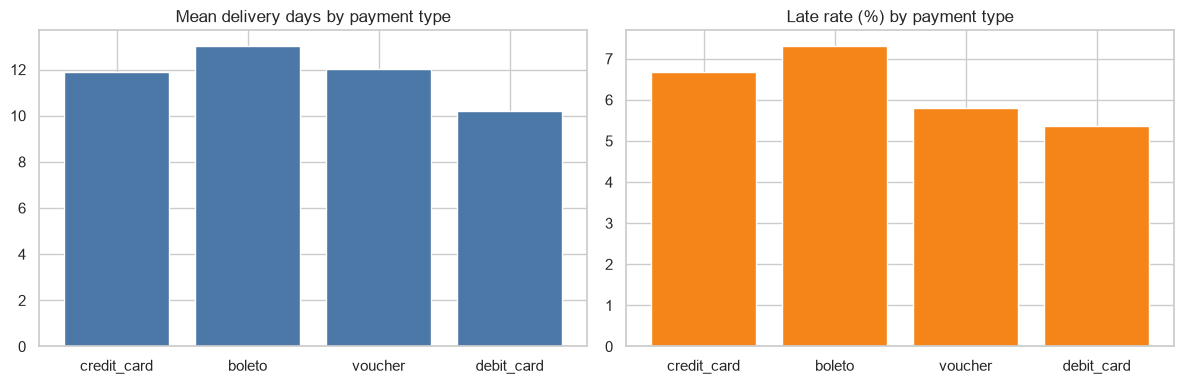

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(payment_summary["payment_type"], payment_summary["mean_delivery_days"], color="#4C78A8")
axes[0].set_title("Mean delivery days by payment type")
axes[1].bar(payment_summary["payment_type"], payment_summary["late_rate"], color="#F58518")
axes[1].set_title("Late rate (%) by payment type")
plt.tight_layout()
plt.show()


`boleto` payment is obviously slower and later than other payment methods, and the order counts of payment types especially of `credit_card` and `boleto` is large enough to trust the difference.

Boleto is a Brazilian bank-slip payment method that isn't confirmed instantly like a card, so if there's a gap it likely shows up as slower `processing_time` (purchase → approval) rather than the shipping leg itself

### 4.1 Verifying: is the Boleto gap actually in processing time?

The claim above is a guess unless checked: does Boleto's slowdown show up in
`processing_time` (purchase -> approval, where a bank-slip payment has to
clear) rather than `handling_time` (approval -> carrier) or `shipping_time`
(carrier -> customer)? 

Approval/carrier timestamps aren't in the consolidated
file, so `data/olist_orders_dataset.csv` is merged in here and group by `payment_type`.

In [21]:
orders_raw = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    usecols=["order_id", "order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date"],
    parse_dates=["order_purchase_timestamp", "order_approved_at",
                 "order_delivered_carrier_date", "order_delivered_customer_date"],
)

stage_payment = order_payment.merge(orders_raw, on="order_id", how="inner")
stage_payment["processing_time"] = (
    stage_payment["order_approved_at"] - stage_payment["order_purchase_timestamp"]
).dt.total_seconds() / 86_400
stage_payment["handling_time"] = (
    stage_payment["order_delivered_carrier_date"] - stage_payment["order_approved_at"]
).dt.total_seconds() / 86_400
stage_payment["shipping_time"] = (
    stage_payment["order_delivered_customer_date"] - stage_payment["order_delivered_carrier_date"]
).dt.total_seconds() / 86_400

stage_cols = ["processing_time", "handling_time", "shipping_time"]
valid_stages = (stage_payment[stage_cols] >= 0).all(axis=1)
print(f"{valid_stages.mean():.1%} of matched orders have valid (non-negative) stage timestamps")
stage_payment = stage_payment.loc[valid_stages]


98.6% of matched orders have valid (non-negative) stage timestamps


  payment_type  processing_time  handling_time  shipping_time  orders  \
0       boleto         1.340125       2.816694       9.396507   18887   
1  credit_card         0.162992       2.863380       9.384449   73252   
2   debit_card         0.282944       2.747601       7.714334    1401   
3      voucher         0.376735       2.794837       9.367552    1482   

       total  
0  13.553325  
1  12.410821  
2  10.744880  
3  12.539125  


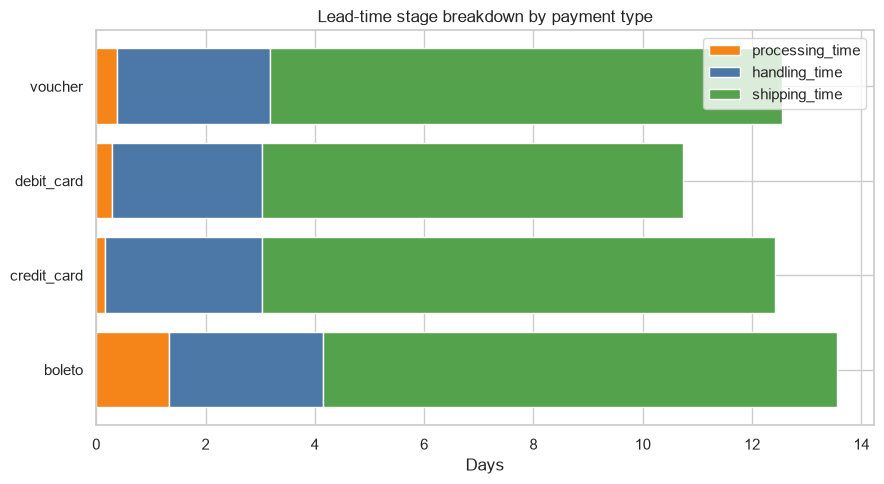

In [22]:
stage_by_payment = stage_payment.groupby("payment_type").agg(
    processing_time=("processing_time", "mean"),
    handling_time=("handling_time", "mean"),
    shipping_time=("shipping_time", "mean"),
    orders=("order_id", "size"),
).reset_index()
stage_by_payment["total"] = stage_by_payment[stage_cols].sum(axis=1)
print(stage_by_payment)

fig, ax = plt.subplots(figsize=(9, 5))
left = pd.Series(0, index=stage_by_payment.index)
colors = {"processing_time": "#F58518", "handling_time": "#4C78A8", "shipping_time": "#54A24B"}
for stage in stage_cols:
    ax.barh(stage_by_payment["payment_type"], stage_by_payment[stage], left=left,
            label=stage, color=colors[stage])
    left += stage_by_payment[stage]
ax.set_xlabel("Days")
ax.set_title("Lead-time stage breakdown by payment type")
ax.legend()
plt.tight_layout()
plt.show()


| payment_type | processing | handling | shipping | total | orders |
|---|---|---|---|---|---|
| boleto | 1.34d | 2.82d | 9.40d | 13.55d | 18,887 |
| credit_card | 0.16d | 2.86d | 9.38d | 12.41d | 73,252 |
| **gap** | **+1.18d** | -0.05d | +0.01d | +1.14d | |

The entire ~1.14-day total gap between boleto and credit_card is
essentially all in `processing_time` (+1.18d) — `handling_time` and
`shipping_time` are statistically flat between the two (differences of
-0.05d and +0.01d are noise, not signal). 

Once a Boleto payment clears, the rest of the order moves through handling and shipping at the same
pace as a credit-card order. This is safe to state as "Boleto's delay is entirely a payment-confirmation issue.

## 5. Product size vs. review score

Sections 1–2 found weight/volume have a modest but real relationship with
`delivery_days`. Delivery time itself has a much stronger relationship with
`review_score` (Phase 1 EDA notebook: r = -0.33; the dashboard's
Decomposition/shipping-time-bucket chart shows the same pattern). Does
product size carry through to review score directly, or does it wash out
once delivery time is the thing actually driving satisfaction? The original
EDA notebook already checked *price* vs review score this same way and
found essentially nothing (r = -0.034) — checking weight/volume for the same
reason: genuine driver, or another dead end like price was?

### 5.0 Bring in review scores

In [23]:
reviews = pd.read_csv(REVIEWS_PATH, parse_dates=["review_creation_date", "review_answer_timestamp"])
order_reviews = (
    reviews.sort_values("review_answer_timestamp")
    .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]]
)
print(f"{len(order_reviews):,} orders have a review")

# baseline needed for the mediation check below: delivery_days -> review_score,
# computed here (not pulled from another notebook) so this stays self-contained.
# Pearson is the one that feeds the mediation arithmetic (must match the Pearson
# used for weight/volume -> delivery_days); Spearman is just for description.
delivery_review = eligible.drop_duplicates("order_id").merge(order_reviews, on="order_id", how="inner")
delivery_review_corr = delivery_review["delivery_days"].corr(delivery_review["review_score"])
delivery_review_corr_spearman = delivery_review["delivery_days"].corr(delivery_review["review_score"], method="spearman")
print(f"Pearson r  (delivery_days vs review_score): {delivery_review_corr:.3f}")
print(f"Spearman r (delivery_days vs review_score): {delivery_review_corr_spearman:.3f}")


98,673 orders have a review
Pearson r  (delivery_days vs review_score): -0.334
Spearman r (delivery_days vs review_score): -0.235


### 5.1 Weight vs. review score

95,830 orders with both weight and review data
Pearson r (weight vs review_score): -0.056
        weight_bucket  mean_review_score  orders
0     (-0.001, 250.0]           4.199579   20408
1      (250.0, 500.0]           4.184665   18233
2     (500.0, 1100.0]           4.195923   18936
3    (1100.0, 2800.0]           4.153283   19265
4  (2800.0, 184400.0]           4.043290   18988


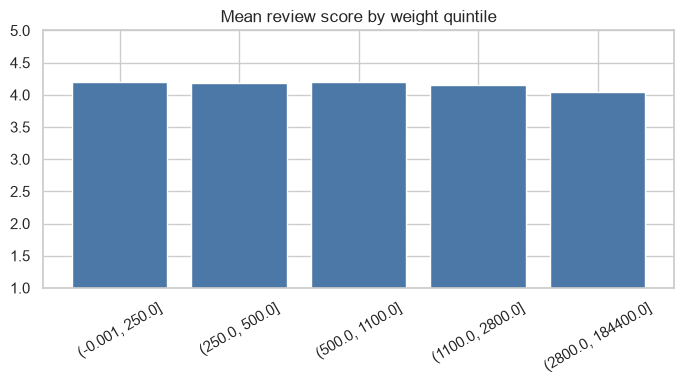

In [24]:
# reuses order_weight and its weight_bucket column from section 1.2 — same bucket
# boundaries, so this is directly comparable to the delivery_days/late_rate results
weight_review = order_weight.merge(order_reviews, on="order_id", how="inner")
print(f"{len(weight_review):,} orders with both weight and review data")

pearson_r_wr = weight_review["total_weight_g"].corr(weight_review["review_score"])
print(f"Pearson r (weight vs review_score): {pearson_r_wr:.3f}")

weight_review_summary = weight_review.groupby("weight_bucket", observed=True).agg(
    mean_review_score=("review_score", "mean"),
    orders=("order_id", "size"),
).reset_index()
print(weight_review_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weight_review_summary["weight_bucket"].astype(str), weight_review_summary["mean_review_score"], color="#4C78A8")
ax.set_title("Mean review score by weight quintile")
ax.set_ylim(1, 5)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 5.2 Volume vs. review score

95,830 orders with both volume and review data
Pearson r (volume vs review_score): -0.057
          volume_bucket  mean_review_score  orders
0      (-0.001, 2520.0]           4.192540   19383
1      (2520.0, 4800.0]           4.192599   19024
2     (4800.0, 10260.0]           4.210455   19168
3    (10260.0, 24276.0]           4.128445   19121
4  (24276.0, 1476000.0]           4.054301   19134


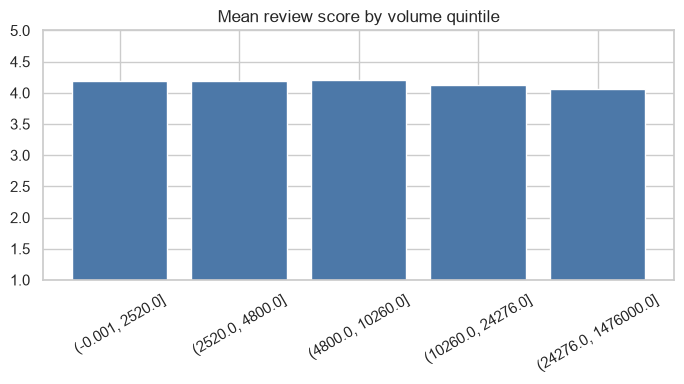

In [25]:
# reuses order_volume and its volume_bucket column from section 2.2
volume_review = order_volume.merge(order_reviews, on="order_id", how="inner")
print(f"{len(volume_review):,} orders with both volume and review data")

pearson_r_vr = volume_review["total_volume_cm3"].corr(volume_review["review_score"])
print(f"Pearson r (volume vs review_score): {pearson_r_vr:.3f}")

volume_review_summary = volume_review.groupby("volume_bucket", observed=True).agg(
    mean_review_score=("review_score", "mean"),
    orders=("order_id", "size"),
).reset_index()
print(volume_review_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(volume_review_summary["volume_bucket"].astype(str), volume_review_summary["mean_review_score"], color="#4C78A8")
ax.set_title("Mean review score by volume quintile")
ax.set_ylim(1, 5)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Observed associations:** Weight and volume each have weak negative Pearson correlations with review score (about -0.056 and -0.057), while delivery days correlate more strongly with review score (about -0.334). Average review scores also decline modestly across the size buckets. Multiplying pairwise correlations does not estimate a mediated effect, so these results do not show whether product size influences reviews through delivery time or through another factor. That question needs an adjusted model.

## 6. Order size & seller mix vs. review score

Same two cuts as Part 3 (`n_items`, single- vs. multi-seller), swapping the
outcome from delivery_days/late_rate to review_score. Part 3 found *more*
items and *multi-seller* orders were both faster and less late than the
1-item/single-seller baseline — if delivery performance is really driving
review score (Part 5), the same direction should show up here too.

### 6.0 Attach review scores to order_composition

In [26]:
# reuses order_composition from Part 3 (already has n_items_bucket from 3.1)
# and order_reviews from 5.0
order_composition_reviewed = order_composition.merge(order_reviews, on="order_id", how="inner")
print(f"{len(order_composition_reviewed):,} of {len(order_composition):,} orders have both composition and review data")


95,830 of 96,476 orders have both composition and review data


### 6.1 Number of items per order vs. review score

  n_items_bucket  mean_review_score  orders
0         1 item           4.213219   86301
1      2–3 items           3.664420    8606
2       4+ items           3.362947     923


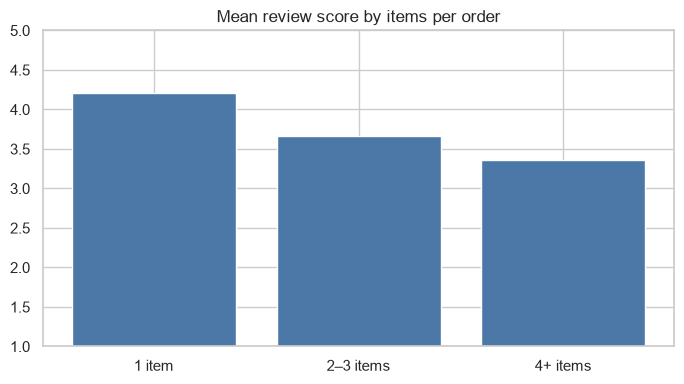

In [27]:
items_review_summary = order_composition_reviewed.groupby("n_items_bucket", observed=True).agg(
    mean_review_score=("review_score", "mean"),
    orders=("order_id", "size"),
).reset_index()
print(items_review_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(items_review_summary["n_items_bucket"].astype(str), items_review_summary["mean_review_score"], color="#4C78A8")
ax.set_title("Mean review score by items per order")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()


### 6.2 Single-seller vs. multi-seller orders vs. review score

Same restriction as 3.2 — multi-item orders only, so a 1-item order
(trivially single-seller) doesn't get counted here.

         seller_mix  mean_review_score  orders
0  Multiple sellers           2.861221    1261
1     Single seller           3.753266    8268


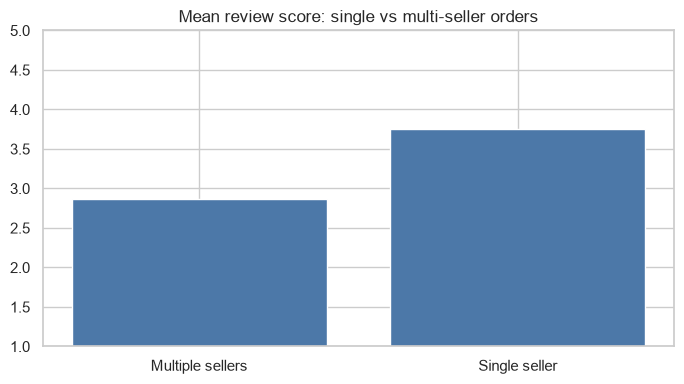

In [28]:
multi_item_orders_reviewed = order_composition_reviewed[order_composition_reviewed["n_items"] > 1].copy()
multi_item_orders_reviewed["seller_mix"] = multi_item_orders_reviewed["n_distinct_sellers"].map(
    lambda n: "Single seller" if n == 1 else "Multiple sellers"
)

seller_mix_review_summary = multi_item_orders_reviewed.groupby("seller_mix").agg(
    mean_review_score=("review_score", "mean"),
    orders=("order_id", "size"),
).reset_index()
print(seller_mix_review_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(seller_mix_review_summary["seller_mix"], seller_mix_review_summary["mean_review_score"], color="#4C78A8")
ax.set_title("Mean review score: single vs multi-seller orders")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()


**opposite direction from Part 3, on both cuts:**

- Items per order: 1 item 4.21 (n=86,301) -> 2–3 items 3.66 (n=8,606) -> 4+ items 3.36 (n=923). 
  Review score drops steadily as items per order increases.
- Seller mix (multi-item orders only): Single seller 3.75 (n=8,268) vs. Multiple sellers 2.86 (n=1,261).

Part 3 found multi-item and multi-seller orders were *faster and less
late* than the 1-item/single-seller baseline. Here they score *lower* on
review, not higher — the reverse of what better delivery performance alone
would predict.

4+ items (n=923) and Multiple sellers (n=1,261) are both notably smaller
samples than their baselines (86,301 and 8,268), so treat the size of the
gaps with some caution, though the direction is consistent across both
cuts.

## 7. Payment method vs. review score

Reuses `primary_payment` from Part 4. Part 4 found Boleto orders were
slower and later than credit card; Part 6 just showed that "better
delivery performance" doesn't reliably mean "better review score" for
order size/seller mix.

This part is for checking whether payment type's review-score
pattern matches its delivery pattern, or breaks the same way Part 6 did.

In [29]:
order_review_outcomes = eligible.drop_duplicates("order_id")[["order_id"]].merge(
    order_reviews, on="order_id", how="inner"
)
order_review_payment = order_review_outcomes.merge(primary_payment, on="order_id", how="inner")
print(f"{len(order_review_payment):,} orders matched to both a review and a primary payment record")

payment_review_summary = order_review_payment.groupby("payment_type").agg(
    mean_review_score=("review_score", "mean"),
    orders=("order_id", "size"),
).sort_values("orders", ascending=False).reset_index()
payment_review_summary


95,752 orders matched to both a review and a primary payment record


,payment_type,mean_review_score,orders
0,credit_card,4.155207,73779
1,boleto,4.155973,19061
2,voucher,4.105866,1483
3,debit_card,4.248425,1429


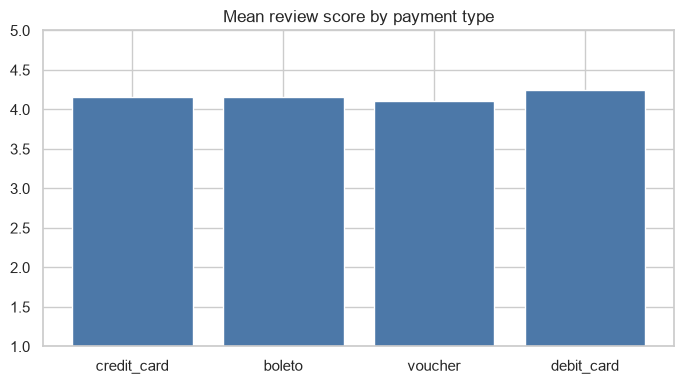

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(payment_review_summary["payment_type"], payment_review_summary["mean_review_score"], color="#4C78A8")
ax.set_title("Mean review score by payment type")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()


Mean review score is nearly equal for the two large payment groups: credit card 4.155 (n = 73,779) and Boleto 4.156 (n = 19,061). Voucher averages 4.106 (n = 1,483), and debit card 4.248 (n = 1,429). Despite Boleto's longer mean delivery time (13.0 versus 11.9 recorded whole days) and higher calendar-date late rate (about 7.3% versus 6.7%), this unadjusted review-score comparison shows little difference between the large groups. The smaller payment groups have less precise estimates.